# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset Pilihan:** Telco Customer Churn
**Kasus:** Klasifikasi (Memprediksi apakah pelanggan akan berhenti berlangganan/churn).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Untuk Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Mengabaikan warnings
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil di-import!')

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook.

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Dataset berhasil dimuat dengan ukuran: {df.shape[0]} baris dan {df.shape[1]} kolom.')
display(df.head())

Dataset berhasil dimuat dengan ukuran: 7043 baris dan 21 kolom.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

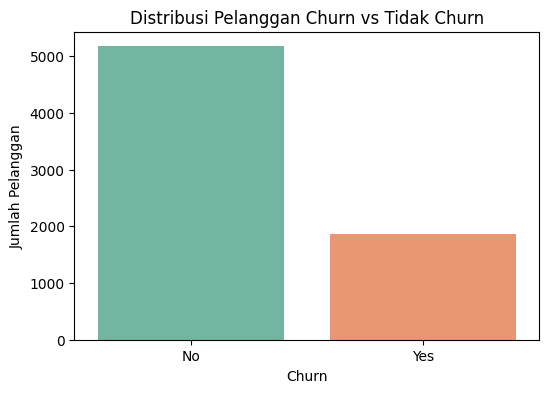

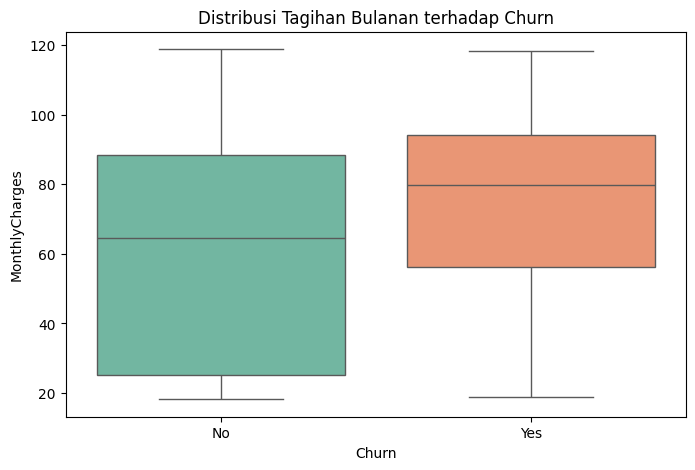

In [3]:
print('--- Info Dataset ---')
df.info()
print('\n' + '='*50 + '\n')

print('--- Missing Values ---')
print(df.isnull().sum())
print('\n' + '='*50 + '\n')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribusi Pelanggan Churn vs Tidak Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Pelanggan')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Distribusi Tagihan Bulanan terhadap Churn')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

In [4]:
df_clean = df.copy()

print('1. Menghapus Kolom ID (Tidak relevan)')
if 'customerID' in df_clean.columns:
    df_clean.drop('customerID', axis=1, inplace=True)

print('2. Menangani Tipe Data dan Missing Values')
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
median_charges = df_clean['TotalCharges'].median()
df_clean['TotalCharges'].fillna(median_charges, inplace=True)

print('3. Encoding Data Kategorikal')
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']
le = LabelEncoder()
y = le.fit_transform(y)
X_encoded = pd.get_dummies(X, drop_first=True)

print('4. Normalisasi Fitur Numerik (Scaling)')
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print('5. Train-Test Split')
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f'   Data Latih (Train): {X_train.shape[0]} baris')
print(f'   Data Uji (Test): {X_test.shape[0]} baris')

print('\n--- Preprocessing Selesai! ---')
display(X_train.head(3))

1. Menghapus Kolom ID (Tidak relevan)
2. Menangani Tipe Data dan Missing Values
3. Encoding Data Kategorikal
4. Normalisasi Fitur Numerik (Scaling)
5. Train-Test Split
   Data Latih (Train): 5634 baris
   Data Uji (Test): 1409 baris

--- Preprocessing Selesai! ---


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2142,0,-0.463037,0.002935,-0.417250,False,False,True,True,False,False,...,False,False,False,True,True,False,False,False,False,True
1623,0,0.880735,1.078118,1.257128,False,False,False,True,False,True,...,False,True,False,True,False,True,True,False,False,False
6074,0,-1.277445,-1.373033,-0.997067,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
